#### **DS4200 Project**
Lifestyle Factors Impacting Sleep Patterns in College Students



In [3]:
# Imports
import pandas as pd
import numpy as np
import altair as alt
import matplotlib.pyplot as plt

In [4]:
# Read in survey reponses csv file
df = pd.read_csv('DS4200 - Data Collection (Responses) - Form Responses 1.csv')
df.head(100)

,Timestamp,What is your gender?,What is your age?,"Where are you located? (City, State, Country)",What is your major?,"On average, how many hours do you sleep each night?","On a scale of 1–10, how would you rate your sleep quality, with 1 being very poor and 10 being excellent?",Approximately how many hours of physical activity do you engage in each day?,"On average, how many hours each day do you spend doing school work/studying?","On a scale of 1–10, how would you rate your stress level, with 1 being very low and 10 being high?","What is your resting heart rate in beats per minute?\n\nIf you are unsure, you can feel your pulse for 10 seconds, and multiply this number by 6",Do you have any sleep disorders?,"If yes to the previous question, which sleep disorder do you have? (ex. Insomnia, Sleep Apnea, etc.)","On average, how many mg of caffeine do you consume each day?\n\nFor reference, 1 latte/(85mg), 1 energy drink/(160mg), 1 brewed coffee/(95mg), etc.","On average, what is your screen time each day?"
0,2/11/2026 20:14:18,Female,19,Boston,Media Arts Production,7,7,1,4,7,78,No,NaN,85mg,10 hrs
1,2/11/2026 20:15:35,Female,19,"Boston, MA, USA",Data Science and Business Administration,6,7,2,5.5,6,84,No,NaN,60mg,15hr
2,2/11/2026 21:27:42,Female,19,"Boston, MA, USA",Business Administration (finance and internati...,8-10,9,1,4,7,87,No,NaN,85,5 hours
3,2/11/2026 21:30:19,Female,19,boston,nursing,7,4,3,1,3,60,No,NaN,200,5
4,2/11/2026 21:31:09,Female,19,Atlanta Georgia,Data Sci,7,10,1,2-3,7,54,No,NaN,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,4/6/2026 21:39:10,Female,21,"Brooklyn, New York, USA",Math,6,3,0,5,8,80,No,NaN,320,6
96,4/6/2026 21:40:58,Female,21,"Brooklyn, NY",Business,8,7,1.5,3,2,55,No,NaN,85,4 hours
97,4/6/2026 21:42:06,Female,22,"Brooklyn, NY, USA",Marine Biology,7,5,1,4,5,75,No,NaN,95,2 hours
98,4/6/2026 21:43:38,Male,21,"Brooklyn, NY, USA",Computer science,6,4,3,5,6,60,No,NaN,0,7 hours


#### ****Data Cleaning****

In [5]:
# Rename columns from questions & drop timestamp col
df = df.drop('Timestamp', axis=1)

df = df.rename(columns={
    'What is your gender?':'Gender',
    'What is your age?': 'Age',
    'Where are you located? (City, State, Country)': 'Location',
    'What is your major?': 'Major',
    'On average, how many hours do you sleep each night?': 'Hours of Sleep',
    'On a scale of 1–10, how would you rate your sleep quality, with 1 being very poor and 10 being excellent?': 'Sleep Quality',
    'Approximately how many hours of physical activity do you engage in each day?': 'Physical Activity',
    'On average, how many hours each day do you spend doing school work/studying?': 'Study Time',
    'On a scale of 1–10, how would you rate your stress level, with 1 being very low and 10 being high?': 'Stress Level',
    'What is your resting heart rate in beats per minute?\n\nIf you are unsure, you can feel your pulse for 10 seconds, and multiply this number by 6': 'Heart Rate',
    'Do you have any sleep disorders?': 'Sleep Disorders',
    'If yes to the previous question, which sleep disorder do you have? (ex. Insomnia, Sleep Apnea, etc.)': 'Disorder Name',
    'On average, how many mg of caffeine do you consume each day?\n\nFor reference, 1 latte/(85mg), 1 energy drink/(160mg), 1 brewed coffee/(95mg), etc.': 'Caffeine',
    'On average, what is your screen time each day?': 'Screen Time'
})

df.head()

,Gender,Age,Location,Major,Hours of Sleep,Sleep Quality,Physical Activity,Study Time,Stress Level,Heart Rate,Sleep Disorders,Disorder Name,Caffeine,Screen Time
0,Female,19,Boston,Media Arts Production,7,7,1,4,7,78,No,NaN,85mg,10 hrs
1,Female,19,"Boston, MA, USA",Data Science and Business Administration,6,7,2,5.5,6,84,No,NaN,60mg,15hr
2,Female,19,"Boston, MA, USA",Business Administration (finance and internati...,8-10,9,1,4,7,87,No,NaN,85,5 hours
3,Female,19,boston,nursing,7,4,3,1,3,60,No,NaN,200,5
4,Female,19,Atlanta Georgia,Data Sci,7,10,1,2-3,7,54,No,NaN,0,6


In [6]:
# Lowercase and strip spaces
df['Location'] = df['Location'].str.lower().str.strip()
df['Location'] = df['Location'].str.title()

# Fix country names
df['Location'] = (
    df['Location']
    .str.replace(r'\bU\.s\.\b', 'USA', regex=True)
    .str.replace(r'\bU\.S.\.\b', 'USA', regex=True)
    .str.replace(r'\bUnited states\b', 'USA', regex=True)
    .str.replace(r'\bUnited States\b', 'USA', regex=True)
    .str.replace(r'\bAmerica\b', 'USA', regex=True)
    .str.replace(r'\bUk\b', 'United Kingdom', regex=True)
    .str.replace(r'\bUs\b', 'USA', regex=True)
    .str.replace(r'\bUsa\b', 'USA', regex=True)
)

# Fix state abbreviations
state_map = {
    r'\bMassachusetts\b':'MA',
    r'\bMa\b':'MA',
    r'\bNew york\b':'NY',
    r'\bNew York\b':'NY',
    r'\bNy\b':'NY',
    r'\bGeorgia\b':'GA',
    r'\bGa\b':'GA',
    r'\bFlorida\b':'FL',
    r'\bIndiana\b':'IN',
    r'\bMinnesota\b':'MN',
    r'\bCalifornia\b':'CA',
    r'\bCa\b':'CA',
    r'\bOntario\b':'ON',
    r'\bOhio\b':'OH',
    r'\bohio\b':'OH',
    r'\bMd\b':'MD',
    r'\bVa\b':'VA',
    r'\bPa\b':'PA',
    r'\bIn\b':'IN'
}
df['Location'] = df['Location'].replace(state_map, regex=True)

# Remove double spaces
df['Location'] = df['Location'].str.replace(r'\s+', ' ', regex=True)

# Map messy full locations to the final clean format (exact match only)
full_map = {
    'Shanghai,China':'Shanghai, China',
    'Boston': 'Boston, MA, USA',
    'Boston, MA': 'Boston, MA, USA',
    'Boston, MA, USA': 'Boston, MA, USA',
    'Boston, MA, u.s.': 'Boston, MA, USA',
    'Boston, MA,': 'Boston, MA, USA',
    'USA MA Boston': 'Boston, MA, USA',
    'Boston MA U.S.': 'Boston, MA, USA',
    'London United Kingdom': 'London, United Kingdom',
    'Atlanta GA': 'Atlanta, GA, USA',
    'NY': 'New York, NY, USA',
    'Davis CA': 'Davis, CA, USA',
    'Chicago USA': 'Chicago, IL, USA',
    'USA, MN': 'MN, USA',
    'Staten Island, NY': 'Staten Island, NY, USA',
    'Los Angeles': 'Los Angeles, CA, USA',
    'Sydney, New south wales, Australia': 'Sydney, New South Wales, Australia',
    'San Deigo': 'San Diego, CA, USA',
    'Ithaca': 'Ithaca, NY, USA',
    'London': 'London, United Kingdom',
    'Berkeley, CA': 'Berkeley, CA, USA',
    'Staten island, NY, USA': 'Staten Island, NY, USA',
    'Bloomington, in, USA': 'Bloomington, IN, USA',
    'Bloomington, IN USA': 'Bloomington, IN, USA',
    'Boston, MA, U.S.': 'Boston, MA, USA',
    'Seattle': 'Seattle, WA, USA',
    'Oak hill, VA, USA': 'Oak Hill, VA, USA',
    'Wilton, Ct USA': 'Wilson, CT, USA',
    'Boston, MA USA': 'Boston, MA, USA',
    'Beaver OH USA': 'Beaver, OH, USA',
    'Columbus OH USA': 'Columbus, OH, USA',
    'Millersburg OH USA': 'Millersburg, OH, USA',
    'Los Angelos USA': 'Los Angeles, CA, USA',
    'NY, NY, USA': 'New York, NY, USA',
    'Brooklyn, NY': 'Brooklyn, NY, USA'
}
df['Location'] = df['Location'].replace(full_map)

print(df["Location"].unique())


['Boston, MA, USA' 'Atlanta, GA, USA' 'New York, NY, USA'
 'Shanghai, China' 'London, United Kingdom' 'Chicago, IL, USA' 'MN, USA'
 'Toronto, ON, Canada' 'Los Angeles, CA, USA'
 'Sydney, New South Wales, Australia' 'Davis, CA, USA'
 'San Diego, CA, USA' 'Bloomington, IN, USA' 'Ithaca, NY, USA'
 'Berkeley, CA, USA' 'Waltham, MA, USA'
 'Oxford, Oxfordshire, United Kingdom' 'Staten Island, NY, USA'
 'Kissimmee, FL, USA' 'Baltimore, MD, USA' 'Seattle, WA, USA'
 'Cambridge, Cambridgeshire, United Kingdom' 'Oak Hill, VA, USA'
 'Allston, MA, USA' 'Philadelphia, PA, USA' 'Wilson, CT, USA'
 'Columbus, OH, USA' 'Millersburg, OH, USA' 'Beaver, OH, USA'
 'Basel, Switzerland' 'Lancaster, PA, USA' 'Westborough, MA, USA'
 'Brooklyn, NY, USA']


In [7]:
# Remove letters in Hours of Sleep, replace ranges with the average
df['Hours of Sleep'] = df['Hours of Sleep'].str.lower().str.replace(r'[a-z]', '', regex=True).str.strip()
numbers = df['Hours of Sleep'].str.extract(r'(\d+\.?\d*)-?(\d*\.?\d*)')
numbers = numbers.apply(pd.to_numeric, errors='coerce')
df['Hours of Sleep'] = numbers.mean(axis=1)

In [8]:
# Remove any non-numerical values (ex. letters) in Physical Activity column
df['Physical Activity'] = df['Physical Activity'].astype(str).str.lower().str.strip()
df['Physical Activity'] = df['Physical Activity'].str.replace(r'[^0-9.]', '', regex=True)
df['Physical Activity'] = pd.to_numeric(df['Physical Activity'], errors='coerce')
print(df['Physical Activity'].value_counts())

Physical Activity
1.00     45
2.00     21
1.50      7
0.50      6
0.00      6
3.00      4
12.00     3
0.25      1
30.00     1
28.00     1
16.00     1
14.00     1
4.00      1
24.00     1
2.50      1
Name: count, dtype: int64


In [9]:
# Remove letters in Study Time column, replace ranges with the average
df['Study Time'] = df['Study Time'].str.lower().str.replace(r'[a-z]', '', regex=True).str.strip()
numbers_study = df['Study Time'].str.extract(r'(\d+\.?\d*)-?(\d*\.?\d*)')
numbers_study = numbers_study.apply(pd.to_numeric, errors='coerce')
df['Study Time'] = numbers_study.mean(axis=1)
print(df['Study Time'].value_counts())

Study Time
4.0     24
5.0     17
3.0     15
2.0     11
8.0      7
7.0      5
1.0      3
6.0      3
3.5      3
9.0      3
5.5      2
2.5      2
10.0     2
4.5      1
1.5      1
13.0     1
Name: count, dtype: int64


In [10]:
# Remove non-numerical characters from Heart Rate column
df['Heart Rate'] = df['Heart Rate'].astype(str).str.lower().str.strip()
df['Heart Rate'] = df['Heart Rate'].str.extract(r'(\d+\.?\d*)')
df['Heart Rate'] = pd.to_numeric(df['Heart Rate'], errors='coerce')
print(df['Heart Rate'].value_counts())

Heart Rate
78.0     11
60.0     10
80.0      7
66.0      7
70.0      7
72.0      6
90.0      5
55.0      4
68.0      3
77.0      3
65.0      3
84.0      2
75.0      2
50.0      2
67.0      2
69.0      2
100.0     2
96.0      2
87.0      2
71.0      2
85.0      2
49.0      1
83.0      1
48.0      1
91.0      1
64.0      1
13.0      1
62.0      1
140.0     1
95.0      1
102.0     1
54.0      1
98.0      1
Name: count, dtype: int64


In [11]:
# Fix spelling errors in Disorder Name column
df['Disorder Name'] = df['Disorder Name'].str.lower().str.strip()
df['Disorder Name'] = df['Disorder Name'].replace('insominia','insomnia')
df['Disorder Name'] = df['Disorder Name'].replace('none', np.nan)
print(df["Disorder Name"].unique())

[nan 'insomnia']


In [12]:
# Remove letters from Caffeine column, take averages if given range
df['Caffeine'] = df['Caffeine'].str.lower().str.replace(r'[a-z]', '', regex=True).str.strip()
numbers_caf = df['Caffeine'].str.extract(r'(\d+\.?\d*)-?(\d*\.?\d*)')
numbers_caf = numbers_caf.apply(pd.to_numeric, errors='coerce')
df['Caffeine'] = numbers_caf.mean(axis=1)
df['Caffeine'] = df['Caffeine'].fillna(0)
print(df['Caffeine'].value_counts())

Caffeine
0.0      36
85.0     15
200.0     9
95.0      6
100.0     4
50.0      3
150.0     3
40.0      3
170.0     3
160.0     3
190.0     2
2.0       2
1.0       2
225.0     1
128.0     1
2.5       1
260.0     1
30.0      1
60.0      1
80.0      1
25.0      1
320.0     1
Name: count, dtype: int64


In [13]:
# Remove letters from Screen Time column, take averages if given range
df['Screen Time'] = df['Screen Time'].str.lower().str.replace(r'[a-z]', '', regex=True).str.strip()
numbers_caf = df['Screen Time'].str.extract(r'(\d+\.?\d*)-?(\d*\.?\d*)')
numbers_caf = numbers_caf.apply(pd.to_numeric, errors='coerce')
df['Screen Time'] = numbers_caf.mean(axis=1)
df['Screen Time'] = df['Screen Time'].fillna(0)
print(df['Screen Time'].value_counts())

Screen Time
5.00     18
6.00     16
8.00     14
4.00     10
10.00     9
3.00      5
15.00     3
5.50      3
14.00     3
2.00      3
9.00      3
12.00     3
13.00     3
7.00      2
11.00     1
24.00     1
4.75      1
7.50      1
8.50      1
Name: count, dtype: int64


In [14]:
# Sort majors into categories
df['Major'] = df['Major'].str.lower().str.strip()
df['Major'] = df['Major'].str.replace('&', 'and', regex=False)
df['Major'] = df['Major'].str.replace('+', 'and', regex=False)
df['Major'] = df['Major'].str.replace(',', '', regex=False)
df['Major'] = df['Major'].str.replace(r'\s+', ' ', regex=True)
abbrev_map = {
    r'\bds\b': 'data science',
    r'\becon\b': 'economics',
    r'\bcs\b': 'computer science',
    r'\bce\b': 'computer engineering',
    r'\bba\b': 'business administration',
    r'\bstats\b': 'statistics',
    r'\bpsych\b': 'psychology',
    r'\bpoli sci\b': 'political science',
}

for abbrev, full in abbrev_map.items():
    df['Major'] = df['Major'].str.replace(abbrev, full, regex=True)
major_map = {
    'media arts production': 'Arts & Media',
    'data science and business administration': 'Interdisciplinary',
    'business administration (finance and international business)': 'Business',
    'nursing': 'Health Sciences',
    'data sci': 'Data Science',
    'independent recording and production': 'Arts & Media',
    'economics': 'Social Sciences',
    'business analytics': 'Business',
    'marketing and film': 'Arts & Media',
    'politics philosophy economics and business admin': 'Interdisciplinary',
    'finance': 'Math & Finance',
    'economic statistics': 'Social Sciences',
    'bsc psychology with education': 'Social Sciences',
    'data science and finance': 'Interdisciplinary',
    'data science and economics': 'Interdisciplinary',
    'neuroscience': 'Life Sciences',
    'computer science and design': "Interdisciplinary",
    'health science': 'Health Sciences',
    'computer science and math': 'Interdisciplinary',
    'boston': 'Other/Unknown',
    'quantitative finance': 'Math & Finance',
    'economics (data seince track)': 'Social Sciences',
    'biodiversity and conservation biology major forest conservation major': 'Environmental & Agricultural Sciences',
    'eomputer engineering': 'Engineering',
    'data science and business administration': 'Interdisciplinary',
    'digital mediaandart history': 'Arts & Media',
    'comp sci': "Computer Science",
    'statisticss': 'Math & Finance',
    'explore program': 'Other/Unknown',
    'eecs': 'Engineering',
    'accounting': 'Business',
    'biology': 'Life Sciences',
    'business administration and management with the concentration in marketing': 'Business',
    'Finance and economics': 'Interdisciplinary',
    'supply chain': 'Business',
    'computer science and business administration': 'Interdisciplinary',
    'psychology': 'Social Sciences',
    'interior design': 'Arts & Media',
    'computer science and business admin': 'Interdisciplinary',
    'computer science and psychology': 'Interdisciplinary',
    'ce/cs': 'Engineering',
    'behavioral neuroscience': 'Life Sciences',
    'accounting and finance': 'Math & Finance',
    'biochemistry': 'Life Sciences',
    'business administration': 'Business',
    'computer science and game development': 'Interdisciplinary',
    'applied math': 'Math & Finance',
    'international business': 'Business',
    'computer science and economics': 'Interdisciplinary',
    'history culture and law': 'Social Sciences',
    'chemistry': 'Life Sciences',
    'turfgrass': 'Environmental & Agricultural Sciences',
    'animal science': 'Environmental & Agricultural Sciences',
    'anima science': 'Environmental & Agricultural Sciences',
    'agronomy': 'Environmental & Agricultural Sciences',
    'chemical engineering': 'Engineering',
    'political science': 'Social Sciences',
    'bachelor of arts early music': 'Arts & Media',
    'media production': 'Arts & Media',
    'art history': 'Arts & Media',
    'architecture': 'Arts & Media',
    'bioengineering and biochemistry': 'Interdisciplinary',
    'bioengineering': 'Engineering',
    'marine biology': 'Environmental & Agricultural Sciences',
    'computer science': 'Computer Science',
    'computer engineering': 'Engineering',
    'statistics': 'Math & Finance',
    'engineering': 'Engineering',
    'business': 'Business',
    'finance and economics': 'Interdisciplinary',
    'computer engineering/computer science': 'Interdisciplinary',
    'math': 'Math & Finance'
}

df['Major Category'] = df['Major'].map(major_map).fillna('Other/Unknown')
print(df['Major Category'].value_counts())


Major Category
Interdisciplinary                        19
Business                                 15
Social Sciences                          12
Math & Finance                           11
Arts & Media                              9
Life Sciences                             8
Computer Science                          6
Environmental & Agricultural Sciences     6
Engineering                               6
Health Sciences                           5
Other/Unknown                             2
Data Science                              1
Name: count, dtype: int64


In [15]:
# Further cleaning the Location data:
# to do it i have to use split location data into two rows: one row for  City and States, one row for countries
split_data = df['Location'].str.rsplit(', ', n=1, expand=True)

# Assign to new columns
df['City_State'] = split_data[0]
df['Country'] = split_data[1]
 
# double check if the data are entirely cleaned
# print(df[['Location', 'City_State', 'Country']])
# US map data Cleaning : first i had to convert all the states to their abbreviated letters
us_state_to_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR", "California": "CA",
    "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE", "Florida": "FL", "Georgia": "GA",
    "Hawaii": "HI", "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS", "Missouri": "MO",
    "Montana": "MT", "Nebraska": "NE", "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ",
    "New Mexico": "NM", "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH",
    "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT", "Vermont": "VT",
    "Virginia": "VA", "Washington": "WA", "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY",
    "District of Columbia": "DC",
}
# theni would create reverse mapping from abbreviation to name)
abbrev_to_state = {v: k for k, v in us_state_to_abbrev.items()}

# State  to ANSI/FIPS IDs this is from the vegas
state_to_id = {
    'Alabama': 1, 'Alaska': 2, 'Arizona': 4, 'Arkansas': 5, 'California': 6, 'Colorado': 8,
    'Connecticut': 9, 'Delaware': 10, 'Florida': 12, 'Georgia': 13, 'Hawaii': 15, 'Idaho': 16,
    'Illinois': 17, 'Indiana': 18, 'Iowa': 19, 'Kansas': 20, 'Kentucky': 21, 'Louisiana': 22,
    'Maine': 23, 'Maryland': 24, 'Massachusetts': 25, 'Michigan': 26, 'Minnesota': 27,
    'Mississippi': 28, 'Missouri': 29, 'Montana': 30, 'Nebraska': 31, 'Nevada': 32,
    'New Hampshire': 33, 'New Jersey': 34, 'New Mexico': 35, 'New York': 36, 'North Carolina': 37,
    'North Dakota': 38, 'Ohio': 39, 'Oklahoma': 40, 'Oregon': 41, 'Pennsylvania': 42,
    'Rhode Island': 44, 'South Carolina': 45, 'South Dakota': 46, 'Tennessee': 47, 'Texas': 48,
    'Utah': 49, 'Vermont': 50, 'Virginia': 51, 'Washington': 53, 'West Virginia': 54,
    'Wisconsin': 55, 'Wyoming': 56
}
# So I need to define a function that cleans 'City_State' data to extract the State Name
def extract_state(val):
    # Check for full names
    for state in state_to_id.keys():
        if state.lower() in val.lower():
            return state
    # check for abbreviations (e.g., "MA" in "Boston, MA")
    for abbrev, name in abbrev_to_state.items():
        # Match " MA", ", MA", or just "MA"
        if f" {abbrev}" in val.upper() or f", {abbrev}" in val.upper() or val.upper() == abbrev:
            return name


df['StateName'] = df['City_State'].apply(extract_state)
df['state_id'] = df['StateName'].map(state_to_id)

### Interactive Map Using Altair

In [16]:
from vega_datasets import data

In [25]:
# First I wanted to create a world map dislaying all the countries we have data of.
country_id_map = {
    'USA': 840,
    'United Kingdom': 826,
    'Canada': 124,
    'Australia': 36,
    'China': 156,
    'Switzerland': 756
}# i searched the ISO number for all the countries our data include
df['id'] = df['Country'].map(country_id_map)

#I want to display the sleep quality, the study time, and the count of how many respondents  in ta when users click on the area
country_averages = df.dropna(subset=['id']).groupby(['id', 'Country']).agg(
    AvgSleepQuality=('Sleep Quality', 'mean'),
    AvgStudyHours=('Study Time', 'mean'),
    ParticipantCount=('id', 'count')
).reset_index()

country_averages = country_averages.rename(columns={'Country': 'CountryName'})

# from the altair lecture, i imported the vegas_dataset to display this worldmap
world_topo = alt.topo_feature(data.world_110m.url, 'countries')



In [27]:
#US Map
# I want to show sleep quality, sleep hours, and study time
state_averages = df.dropna(subset=['state_id']).groupby(['state_id', 'StateName']).agg(
    AvgSleepQuality=('Sleep Quality', 'mean'),
    AvgSleepHours=('Hours of Sleep', 'mean'),
    AvgStudyHours=('Study Time', 'mean'),
    ParticipantCount=('state_id', 'count') # i'm adding the count of the participants so that the users would not be mislead by our data thinking it represent a higher population/ group of people
).reset_index()

state_averages = state_averages.rename(columns={'state_id': 'id'})

In [31]:
# 1. Define the Dropdown Selection
map_dropdown = alt.binding_select(options=['World', 'US States'], name='Select Map: ')
map_select = alt.selection_point(fields=['map_type'], bind=map_dropdown, value='World')

# --- US MAP ---
states_topo = alt.topo_feature(data.us_10m.url, 'states')
click_state = alt.selection_point(fields=['id'], empty=False)

us_background = alt.Chart(states_topo).mark_geoshape(
    fill='#f0f0f0', stroke='black', strokeWidth=0.5)

us_foreground = alt.Chart(states_topo).mark_geoshape(
    stroke='black', strokeWidth=0.5
).transform_lookup(
    lookup='id',
    from_=alt.LookupData(state_averages, 'id', 
        ['AvgSleepQuality', 'AvgSleepHours', 'AvgStudyHours', 'StateName', 'ParticipantCount']) 
).encode(
    color=alt.condition(
        click_state,
        alt.value('orange'),
        alt.condition(
            "datum.AvgSleepQuality == null",
            alt.value('#f0f0f0'),
            alt.Color('AvgSleepQuality:Q', scale=alt.Scale(scheme='teals'), title='Avg Sleep Quality (0~10)')
        )
    ),
    tooltip=[
        alt.Tooltip('StateName:N', title='State'),
        alt.Tooltip('ParticipantCount:Q', title='Total Respondents'), 
        alt.Tooltip('AvgSleepQuality:Q', title='Avg Sleep Quality', format='.2f'),
        alt.Tooltip('AvgSleepHours:Q', title='Avg Sleep Hours', format='.2f'),
        alt.Tooltip('AvgStudyHours:Q', title='Avg Study Hours', format='.2f') 
    ]
).add_params(click_state)

# i put US map in a layer with its specific projection and map_type tag
us_view = alt.layer(us_background, us_foreground).project(
    type='albersUsa'
).transform_calculate(
    map_type="'US States'"
).transform_filter(
    map_select)


# --- WORLD MAP  ---
#basically the same thing i just copied the code and iterated based onthe us code
world_topo = alt.topo_feature(data.world_110m.url, 'countries')
click_world = alt.selection_point(fields=['id'], empty=False)

world_background = alt.Chart(world_topo).mark_geoshape(
    fill='#f0f0f0', stroke='black', strokeWidth=0.3 )

world_foreground = alt.Chart(world_topo).mark_geoshape(
    stroke='black', strokeWidth=0.5
).transform_lookup(
    lookup='id',
    from_=alt.LookupData(country_averages, 'id', ['AvgSleepQuality', 'AvgStudyHours', 'CountryName','ParticipantCount'])
).encode(
    color=alt.condition(
        click_world,
        alt.value('orange'),
        alt.condition(
            "datum.AvgSleepQuality == null", 
            alt.value('white'), 
            alt.Color('AvgSleepQuality:Q', scale=alt.Scale(scheme='teals'), title='Avg Sleep Quality (0~10)')) ),
    tooltip=[
        alt.Tooltip('CountryName:N', title='Country'),
        alt.Tooltip('ParticipantCount:Q', title='Respondents'),
        alt.Tooltip('AvgSleepQuality:Q', title='Avg Sleep Quality', format='.2f'),
        alt.Tooltip('AvgStudyHours:Q', title='Avg Study Hours', format='.2f')  ]).add_params(click_world)

# Wrap World Map in a layer with its specific projection and map_type tag
world_view = alt.layer(world_background, world_foreground).project(
    type='equalEarth'
).transform_calculate(
    map_type="'World'"
).transform_filter(
    map_select)


# Combine the charts:
final_combined_map = alt.layer(
    world_view, us_view
).add_params(
    map_select
).properties(
    width=900, height=500,
    title='Average Sleep Quality Across Different Locations'
).configure_view(stroke=None)

final_combined_map.display()
final_combined_map.save('map.html')

alt.LayerChart(...)

In [20]:
df

,Gender,Age,Location,Major,Hours of Sleep,Sleep Quality,Physical Activity,Study Time,Stress Level,Heart Rate,Sleep Disorders,Disorder Name,Caffeine,Screen Time,Major Category,City_State,Country,StateName,state_id,id
0,Female,19,"Boston, MA, USA",media arts production,7.0,7,1.0,4.0,7,78.0,No,NaN,85.0,10.0,Arts & Media,"Boston, MA",USA,Massachusetts,25.0,840
1,Female,19,"Boston, MA, USA",data science and business administration,6.0,7,2.0,5.5,6,84.0,No,NaN,60.0,15.0,Interdisciplinary,"Boston, MA",USA,Massachusetts,25.0,840
2,Female,19,"Boston, MA, USA",business administration (finance and internati...,9.0,9,1.0,4.0,7,87.0,No,NaN,85.0,5.0,Business,"Boston, MA",USA,Massachusetts,25.0,840
3,Female,19,"Boston, MA, USA",nursing,7.0,4,3.0,1.0,3,60.0,No,NaN,200.0,5.0,Health Sciences,"Boston, MA",USA,Massachusetts,25.0,840
4,Female,19,"Atlanta, GA, USA",data sci,7.0,10,1.0,2.5,7,54.0,No,NaN,0.0,6.0,Data Science,"Atlanta, GA",USA,Georgia,13.0,840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Female,21,"Brooklyn, NY, USA",math,6.0,3,0.0,5.0,8,80.0,No,NaN,320.0,6.0,Math & Finance,"Brooklyn, NY",USA,New York,36.0,840
96,Female,21,"Brooklyn, NY, USA",business,8.0,7,1.5,3.0,2,55.0,No,NaN,85.0,4.0,Business,"Brooklyn, NY",USA,New York,36.0,840
97,Female,22,"Brooklyn, NY, USA",marine biology,7.0,5,1.0,4.0,5,75.0,No,NaN,95.0,2.0,Environmental & Agricultural Sciences,"Brooklyn, NY",USA,New York,36.0,840
98,Male,21,"Brooklyn, NY, USA",computer science,6.0,4,3.0,5.0,6,60.0,No,NaN,0.0,7.0,Computer Science,"Brooklyn, NY",USA,New York,36.0,840


In [47]:
# create the selection brush
# 'encodings=["x"]' to drag left-to-right to select a range
brush = alt.selection_interval(encodings=['x'])

# so i want the sleep quality to be the controller of all other graphs
base = alt.Chart(df).mark_bar().encode(
    y=alt.Y('count()', title='Frequency')
).properties(
    width=300,
    height=250
)

# --- Sleep Quality (THE CONTROLLER) ---
# This is the chart where the user selects the range
sleep_chart = base.encode(
    x=alt.X('Sleep Quality:Q', bin=alt.Bin(step=1), title='Sleep Quality (1-10)'),
    color=alt.condition(brush, alt.value('teal'), alt.value('lightgray'))
).add_params(
    brush 
).properties(
    title='Select Sleep Quality Range Here'
)

# --- Screen Time (LISTENER) ---
screen_chart = base.encode(
    x=alt.X('Screen Time:Q', bin=alt.Bin(maxbins=15), title='Daily Screen Time (Hours)'),
    color=alt.value('skyblue')
).transform_filter(
    brush 
).properties(
    title='Screen Time (Filtered)'
)

# --- Caffeine (LISTENER) ---
caffeine_chart = base.encode(
    x=alt.X('Caffeine:Q', bin=alt.Bin(maxbins=15), title='Daily Caffeine (mg)'),
    color=alt.value('orange')
).transform_filter(
    brush
).properties(
    title='Caffeine Consumption (Filtered)'
)

# --- Heart Rate (LISTENER) ---
heart_chart = base.encode(
    x=alt.X('Heart Rate:Q', bin=alt.Bin(maxbins=15), title='Resting Heart Rate (BPM)'),
    color=alt.value('salmon')
).transform_filter(
    brush
).properties(
    title='Heart Rate (Filtered)'
)

# Combine ALL charts 
interactive_lifestyle_dashboard = (sleep_chart | screen_chart) & (caffeine_chart | heart_chart)

interactive_lifestyle_dashboard = interactive_lifestyle_dashboard.configure_view(
    stroke=None
).configure_title(
    fontSize=16,
    anchor='start'
)

alt.VConcatChart(...)

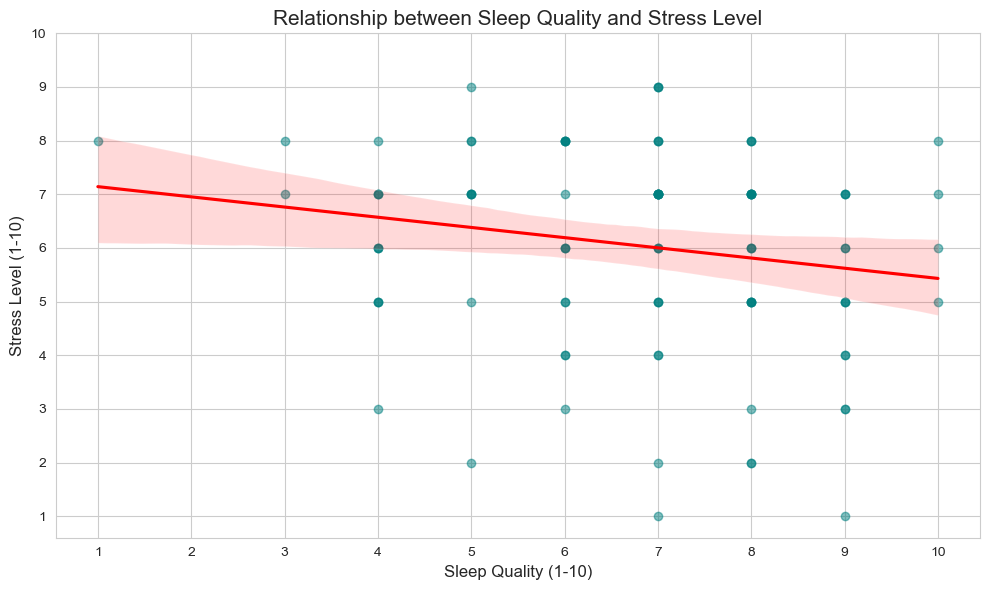

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plot_df = df.copy()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.regplot(
    data=plot_df,
    x='Sleep Quality',
    y='Stress Level',
    scatter_kws={'alpha':0.5, 'color': 'teal'}, 
    line_kws={'color': 'red'} 
)

plt.title('Relationship between Sleep Quality and Stress Level', fontsize=15)
plt.xlabel('Sleep Quality (1-10)', fontsize=12)
plt.ylabel('Stress Level (1-10)', fontsize=12)
plt.xticks(range(1, 11))
plt.yticks(range(1, 11))

plt.tight_layout()

In [22]:
# Interactive scatterplot with dropdown of major category (with tooltip to see exact major)
df['Major Category'] = df['Major Category'].fillna('Other/Unknown')
input_dropdown = alt.binding_select(options = [None, 
'Interdisciplinary', 
'Business', 
'Social Sciences',
'Math & Finance',
'Arts & Media',
'Life Sciences',
'Computer Science',
'Environmental & Agricultural Sciences',
'Health Sciences',
'Other/Unknown',
'Engineering',
'Data Science'],
 name = 'Category of Major: ',
 labels = ['All', 'Interdisciplinary', 
'Business', 
'Social Sciences',
'Math & Finance',
'Arts & Media',
'Life Sciences',
'Computer Science',
'Environmental & Agricultural Sciences',
'Health Sciences',
'Other/Unknown',
'Engineering',
'Data Science'])

selection = alt.selection_point(fields=['Major Category'], bind = input_dropdown)

scatter = alt.Chart(df).mark_circle().encode(
    x = alt.X('Study Time:Q'),
    y = alt.Y('Hours of Sleep:Q'),
    color = alt.condition(selection, alt.Color('Major Category:N', scale=alt.Scale(scheme='category20')), alt.value('grey')),
    opacity = alt.condition(selection, alt.value(1), alt.value(0.3)),
    tooltip = [alt.Tooltip('Major:N'), alt.Tooltip('Sleep Quality:O')]
).add_params(
    selection
).properties(
    title = 'Scatter Plot of Study Time and Hours of Sleep by Major'
)

scatter.save('scatter.html')


In [23]:
# For stacked bar plot in D3, calculate averages:
cols = ['Physical Activity', 'Study Time', 'Screen Time', 'Hours of Sleep']
print(df.groupby('Gender')[cols].mean().round(2))

        Physical Activity  Study Time  Screen Time  Hours of Sleep
Gender                                                            
Female               2.43        4.49         6.44            7.31
Male                 3.05        4.58         8.50            7.14


In [24]:
import altair as alt

heatmap = alt.Chart(df).mark_rect().encode(
    x=alt.X('Hours of Sleep:O', title='Hours of Sleep'),
    y=alt.Y('Sleep Quality:O', title='Sleep Quality', sort='descending'),
    color=alt.Color('count():Q', scale=alt.Scale(scheme='teals'), title='Count'),
    tooltip=[
        alt.Tooltip('Hours of Sleep:O'),
        alt.Tooltip('Sleep Quality:O'),
        alt.Tooltip('count():Q', title='Count')
    ]
).properties(
    title='Hours of Sleep vs Sleep Quality',
    width=500,
    height=400
)

heatmap.save('heatmap.html')